In [1]:
# 한글 폰트 설치
!sudo apt-get -qq -y install fonts-nanum

# matplotlib 폰트 캐시 삭제
!rm -rf ~/.cache/matplotlib

import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

In [2]:
import matplotlib.font_manager as fm

fonts = [f.name for f in fm.fontManager.ttflist]
print("NanumBarunGothic" in fonts)

True


In [3]:
!pip install catboost

In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

from catboost import CatBoostClassifier

In [5]:
train = pd.read_csv("/content/train_preprocessed_ff.csv")
test = pd.read_csv("/content/test_preprocessed_ff.csv")

In [6]:
print(train.shape)
print(test.shape)

(256351, 69)
(90067, 68)


In [9]:
X = train.drop(columns=["임신 성공 여부"])
y = train["임신 성공 여부"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

categorical_cols = [
    "시술 당시 나이",
    "시술 유형",
    "배아 생성 주요 이유",
    "난자 출처",
    "정자 출처",
    "난자 기증자 나이",
    "정자 기증자 나이"
]

for col in categorical_cols:

    X_train[col] = (
        X_train[col]
        .astype("Int64")
        .astype(str)
        .replace("<NA>", "Missing")
    )

    X_valid[col] = (
        X_valid[col]
        .astype("Int64")
        .astype(str)
        .replace("<NA>", "Missing")
    )

    test[col] = (
        test[col]
        .astype("Int64")
        .astype(str)
        .replace("<NA>", "Missing")
    )


In [10]:
from sklearn.metrics import roc_auc_score

model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=100
)

model.fit(
    X_train,
    y_train,
    cat_features=categorical_cols,
    eval_set=(X_valid, y_valid),
    use_best_model=True
)

pred = model.predict_proba(X_valid)[:, 1]

auc = roc_auc_score(y_valid, pred)

print(f"AUC : {auc:.5f}")

0:	test: 0.6999735	best: 0.6999735 (0)	total: 534ms	remaining: 4m 26s
100:	test: 0.7339559	best: 0.7339559 (100)	total: 40.2s	remaining: 2m 38s
200:	test: 0.7354122	best: 0.7354122 (200)	total: 1m 19s	remaining: 1m 58s
300:	test: 0.7359650	best: 0.7359843 (297)	total: 1m 59s	remaining: 1m 18s
400:	test: 0.7361305	best: 0.7361331 (395)	total: 2m 38s	remaining: 39.2s
499:	test: 0.7361568	best: 0.7361690 (497)	total: 3m 17s	remaining: 0us

bestTest = 0.7361690413
bestIteration = 497

Shrink model to first 498 iterations.
AUC : 0.73617


# Feature Importance 분석

In [11]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
37,이식된 배아 수,48.690802
60,배아 이식 경과일,12.243926
39,저장된 배아 수,7.030733
0,시술 당시 나이,5.873398
49,정자 출처,3.478796
43,수집된 신선 난자 수,3.094369
34,총 생성 배아 수,2.859978
48,난자 출처,2.211280
23,배아 생성 주요 이유,2.165370
45,혼합된 난자 수,1.473895


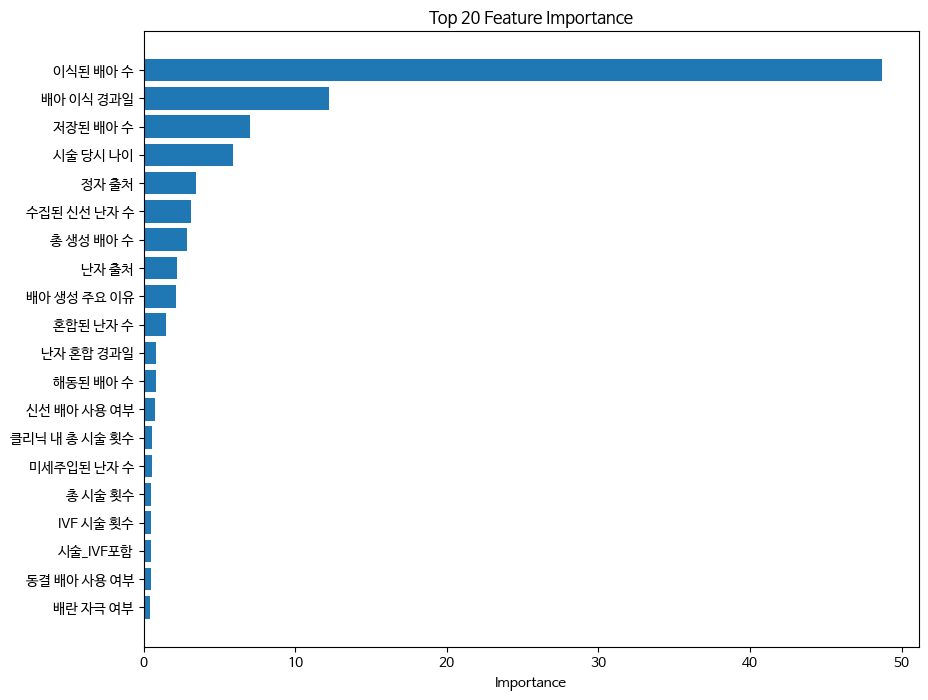

In [12]:
import matplotlib.pyplot as plt

top20 = feature_importance.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top20["Feature"][::-1],
    top20["Importance"][::-1]
)

plt.xlabel("Importance")
plt.title("Top 20 Feature Importance")

plt.show()

In [13]:
feature_importance.to_csv(
    "CatBoost_feature_importance_f.csv",
    index=False,
    encoding="utf-8-sig"
)

In [14]:
print(X_train[categorical_cols].dtypes)

시술 당시 나이       object
시술 유형          object
배아 생성 주요 이유    object
난자 출처          object
정자 출처          object
난자 기증자 나이      object
정자 기증자 나이      object
dtype: object
